In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [4]:
clean_visits = pd.read_csv("../data/clean/visitation_data_clean.csv")
national_parks = pd.read_csv("../data/clean/national_parks_clean.csv")
combined = pd.read_csv("../data/clean/combined_nps_visitation.csv")

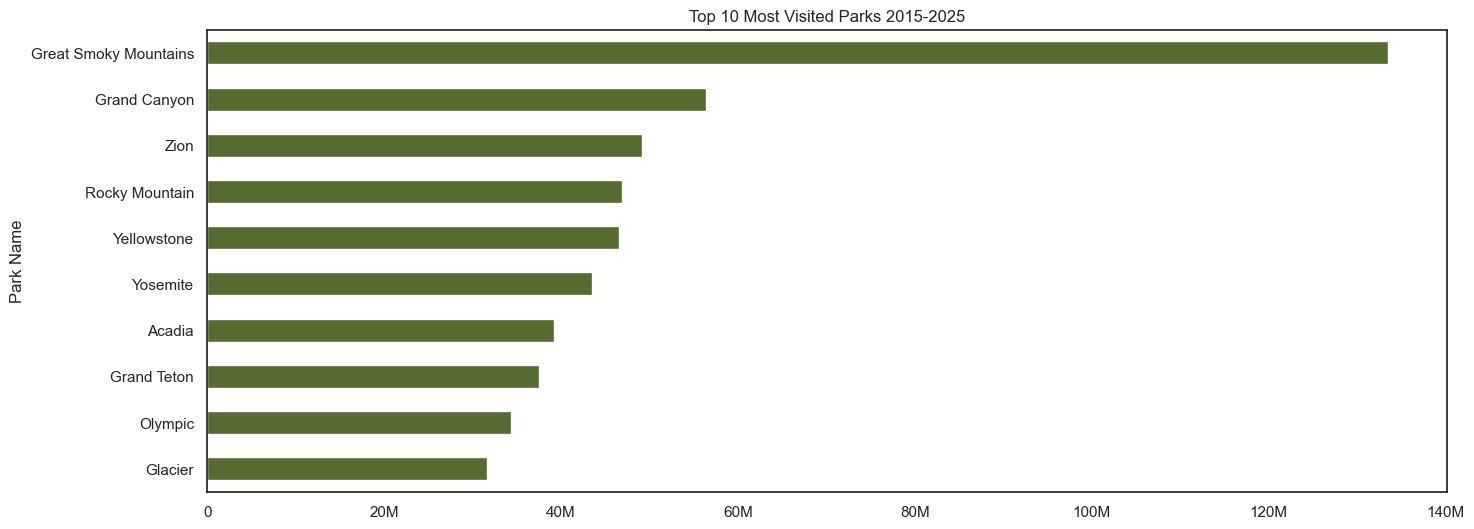

In [26]:
#top 10 parks by visitation numbers
sns.set_theme(style="white", palette="Greens")
park_vis = clean_visits.groupby('Park Name')['Recreation Visits'].sum()
top_park_vis = park_vis.sort_values(ascending=False).head(10)
top_park_vis.index = top_park_vis.index.str.replace(' NP', '', regex=False)
plt.figure(figsize=(16,6))
top_park_vis.sort_values().plot(kind='barh', color ='forestgreen')
plt.title("Top 10 Most Visited Parks 2015-2025")
plt.xlabel("Total Recreational Visits")
ax = top_park_vis.sort_values().plot(kind='barh',color='darkolivegreen')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: '0' if x == 0 else f'{x/1e6:.0f}M'))
plt.show()

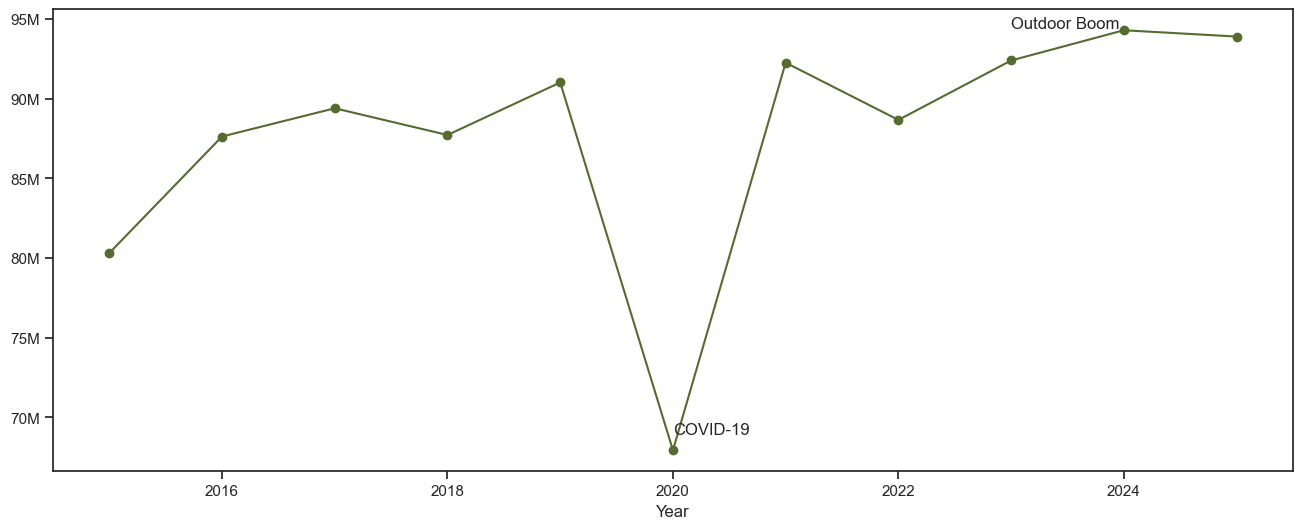

In [25]:
#Visitation Over Time
yearly_visits = clean_visits.groupby('Year')['Recreation Visits'].sum()
plt.figure(figsize=(16,6))
ax = yearly_visits.plot(kind='line', marker='o',color='darkolivegreen')
ax.annotate('COVID-19',xy=(2020, yearly_visits.loc[2020]),xytext=(2020, yearly_visits.loc[2020] +1_000_000))
ax.annotate('Outdoor Boom',xy=(2023, yearly_visits.loc[2023]),xytext=(2023, yearly_visits.loc[2023] +2_000_000))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: '0' if y == 0 else f'{y/1e6:.0f}M'))

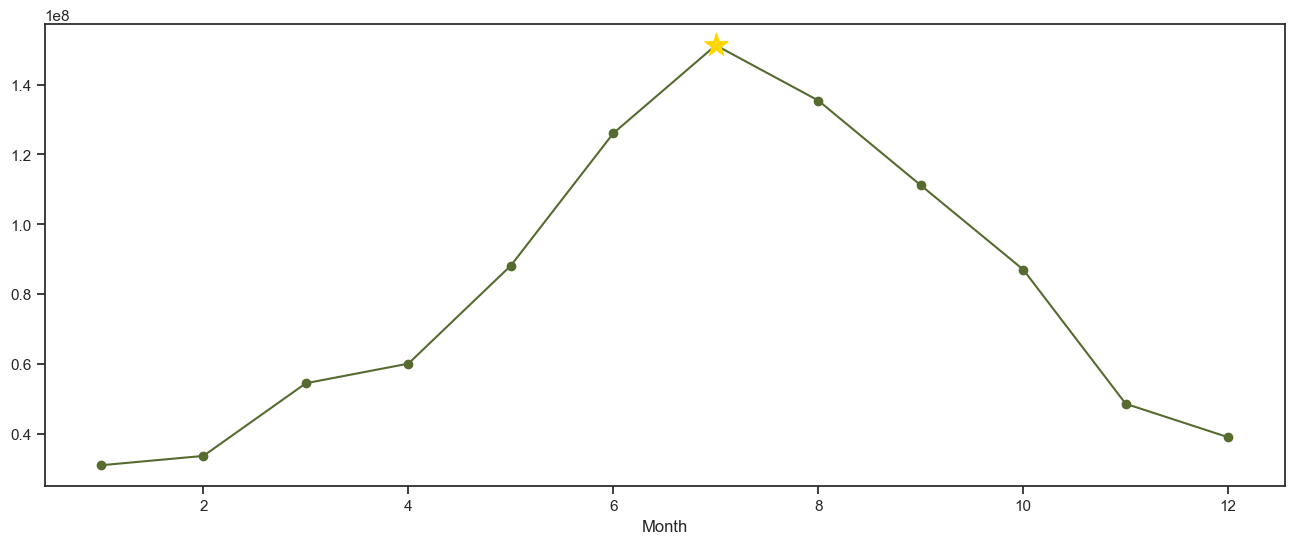

In [24]:
#Monthly Visitation
monthly_visits = clean_visits.groupby('Month')['Recreation Visits'].sum()
plt.figure(figsize=(16,6))
monthly_visits.plot(kind='line', marker='o',color='darkolivegreen')
july_val = monthly_visits.loc[7]
plt.scatter(7,july_val,marker='*',s=300,color='gold',zorder=5) #star to depict that July is the most popular month to visit national parks

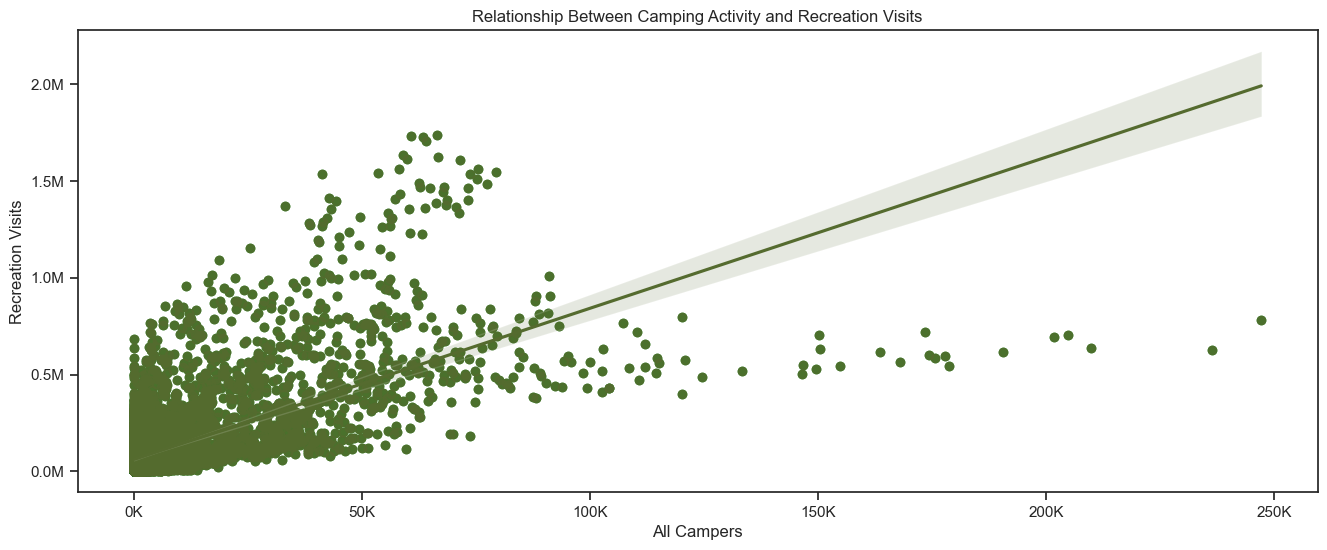

In [23]:
#Campers vs Recreation Visits  
clean_visits['All Campers'] = clean_visits['RV Campers'] + clean_visits['Tent Campers'] + clean_visits['Backcountry']
plt.figure(figsize=(16,6))
plt.scatter(clean_visits['All Campers'], clean_visits['Recreation Visits'], color = 'forestgreen')
plt.title("Relationship Between Camping Activity and Recreation Visits")
plt.xlabel("Total Campers")
plt.ylabel("Recreation Visits")

sns.regplot(x='All Campers',y='Recreation Visits',data=clean_visits, color ='darkolivegreen')

ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000:.0f}K'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y/1e6:.1f}M'))

<Figure size 1000x600 with 0 Axes>

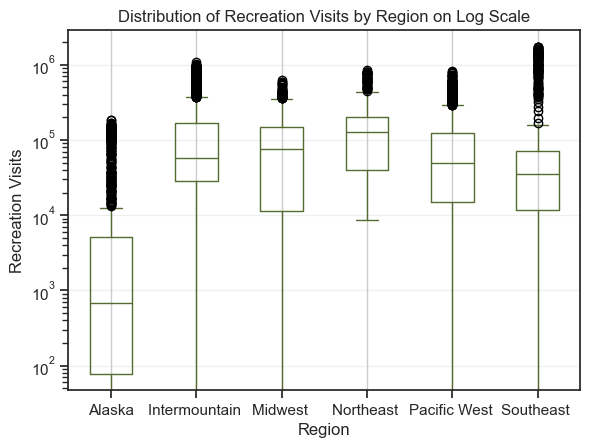

In [22]:
region_visits = clean_visits.groupby('Region')['Recreation Visits'].sum()
plt.figure(figsize=(10,6))
clean_visits.boxplot(column='Recreation Visits',by='Region', color ='darkolivegreen')

plt.yscale('log')
plt.title('Distribution of Recreation Visits by Region on Log Scale')
plt.suptitle('')
plt.xlabel('Region')
plt.ylabel('Recreation Visits')
plt.grid(axis='y', alpha=0.3)
plt.show()

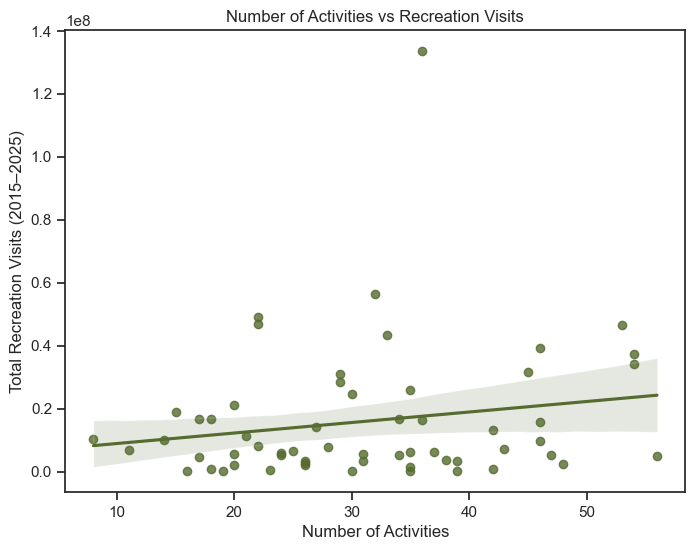

In [21]:
#adding up the visits per park
park_sum = combined.groupby('Park Name').agg({'Recreation Visits':'sum', 'Number of Activities':'first'}).reset_index()
park_sum.head()

#plot visits vs # of activities
plt.figure(figsize=(8,6))
sns.regplot(data =park_sum,x= 'Number of Activities', y='Recreation Visits', color= 'darkolivegreen')
plt.title('Number of Activities vs Recreation Visits')
plt.xlabel('Number of Activities')
plt.ylabel('Total Recreation Visits (2015–2025)')
plt.show()


Text(0.5, 0, 'Acitivy Number')

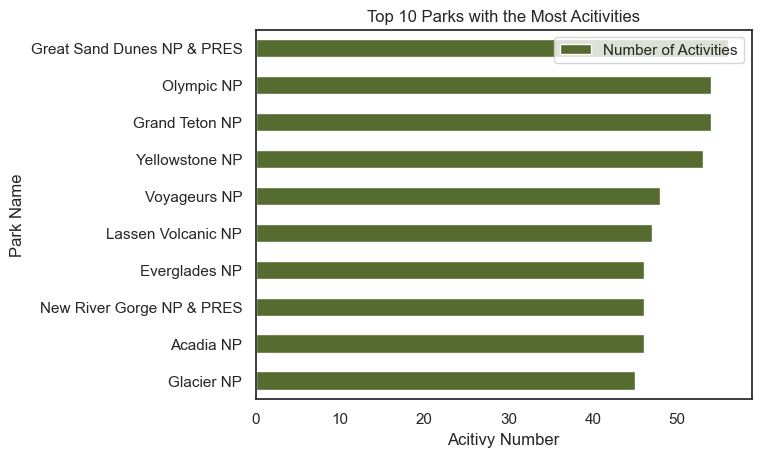

In [60]:
top_act = combined[['Park Name', 'Number of Activities']].sort_values('Number of Activities', ascending = False).drop_duplicates().head(10)
top_act.sort_values('Number of Activities').plot(x='Park Name', y = 'Number of Activities', kind='barh', color='darkolivegreen')
plt.title('Top 10 Parks with the Most Acitivities')
plt.xlabel('Acitivy Number')


Text(0, 0.5, 'Annual Recreation Visits')

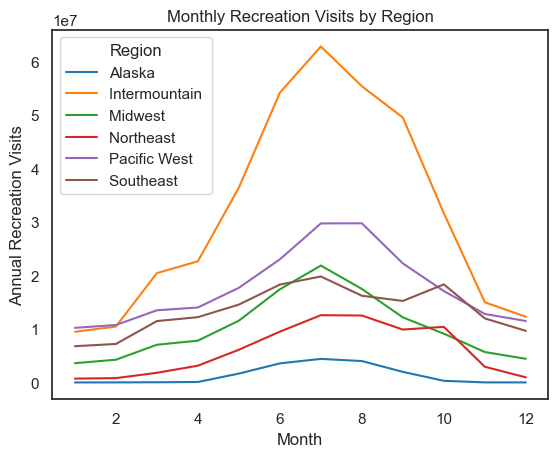

In [58]:
monthly_region = (clean_visits.groupby(['Month','Region'])['Recreation Visits'].sum().reset_index())
sns.lineplot(data=monthly_region,x='Month',y='Recreation Visits',hue='Region', palette='tab10')
plt.title('Monthly Recreation Visits by Region')
plt.xlabel('Month')
plt.ylabel('Annual Recreation Visits')

Text(0.5, 1.0, 'Correlation Matrix')

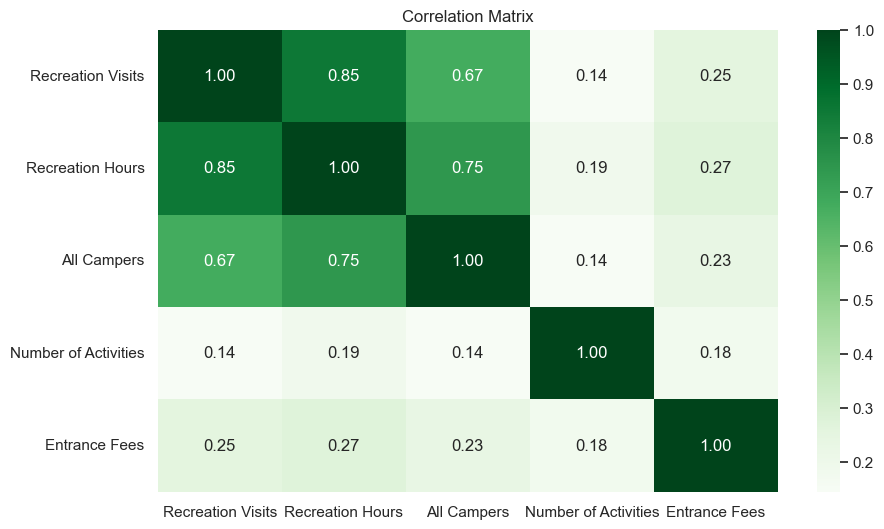

In [40]:
corr_vars = combined[['Recreation Visits','Recreation Hours','All Campers','Number of Activities','Entrance Fees']]
corr_matrix = corr_vars.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix,annot=True,cmap='Greens',fmt='.2f')
plt.title('Correlation Matrix')

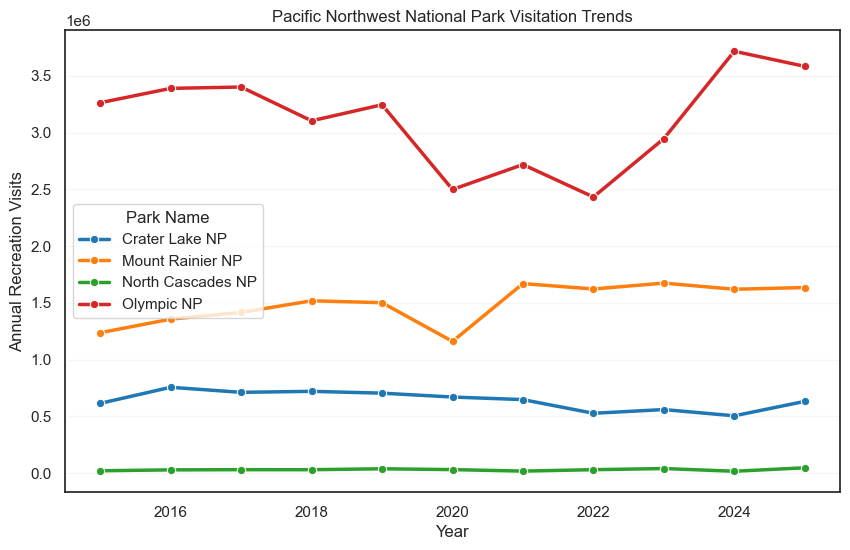

In [57]:
pnw = ['Olympic NP', 'Mount Rainier NP', 'Crater Lake NP', 'North Cascades NP']
pnw_vis = clean_visits[clean_visits['Park Name'].isin(pnw)]
pnw_yearly = (pnw_vis.groupby(['Year', 'Park Name'])['Recreation Visits'].sum().reset_index())
plt.figure(figsize=(10,6))
sns.lineplot(data=pnw_yearly,x='Year',y='Recreation Visits',hue='Park Name', marker='o', linewidth=2.5,palette='tab10')
plt.title('Pacific Northwest National Park Visitation Trends')
plt.xlabel('Year')
plt.ylabel('Annual Recreation Visits')
plt.grid(axis='y', color='lightgray', alpha=0.2)
plt.show()